# HW12 — временные ряды

По методичке `S12-homework.md`: temporal split, **B1–B3**, **R1 (GRU)**, артефакты в `artifacts/`.

### 2.3.1 Импорты, seed и среда

Фиксируем воспроизводимость (`random`, `numpy`, `torch`) и задаём устройство.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for d in (_here, _here / "HW12", _here / "homeworks" / "HW12"):
    if (d / "hw12_run.py").is_file():
        sys.path.insert(0, str(d))
        break
else:
    raise FileNotFoundError("Положите ноутбук рядом с hw12_run.py или запускайте из homeworks/ / корня репо.")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler

from hw12_run import SEED, FAST_DEV_RUN, resolve_hw_paths, run_hw12

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("SEED =", SEED, "| DEVICE =", DEVICE, "| FAST_DEV_RUN =", FAST_DEV_RUN)

SEED = 42 | DEVICE = cpu | FAST_DEV_RUN = True


### 2.3.2 Данные и первичный анализ

Загрузка CSV, `pd.to_datetime` для `date`, сортировка по времени, базовый график.

Dataset file: S12-hw-dataset.csv
N = 4320
Даты: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
NaN по колонкам: {'date': 0, 'target': 0}


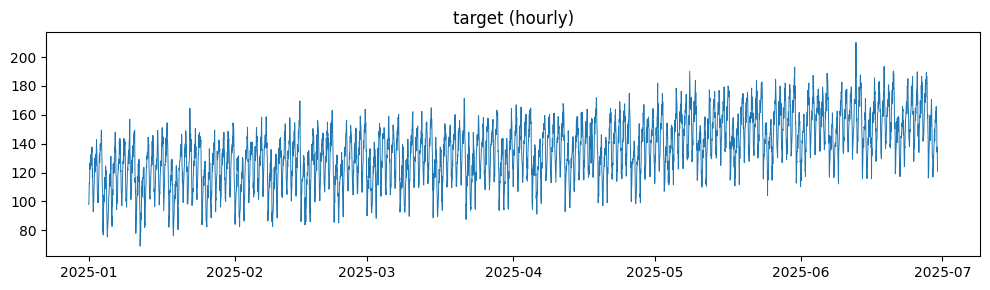

Пример признаков (фрагмент):
     lag_1   lag_7  lag_14  rolling_mean_7  rolling_std_7  dow
20  116.59  125.04  126.50      129.254286       7.422746    2
21  122.83  128.87  126.01      128.938571       7.674595    2
22  106.54  136.40  122.38      125.748571      11.429896    2
23  101.72  133.85  128.28      120.794286      13.391289    2


In [2]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for d in (_here, _here / "HW12", _here / "homeworks" / "HW12"):
    if (d / "hw12_run.py").is_file():
        sys.path.insert(0, str(d))
        break
else:
    raise FileNotFoundError("Положите ноутбук рядом с hw12_run.py или запускайте из homeworks/ / корня репо.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hw12_run import resolve_hw_paths

_, DATA_PATH, _, _ = resolve_hw_paths()
print("Dataset file:", DATA_PATH.name)
assert DATA_PATH.name == "S12-hw-dataset.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("N =", len(df))
print("Даты:", df["date"].min(), "→", df["date"].max())
print("NaN по колонкам:", df.isna().sum().to_dict())

plt.figure(figsize=(10, 3))
plt.plot(df["date"], df["target"], lw=0.7)
plt.title("target (hourly)")
plt.tight_layout()
plt.show()

# Пример лагов / rolling без утечки из будущего (как в B3; полный расчёт — в run_hw12)
feat_demo = pd.DataFrame(
    {
        "lag_1": df["target"].shift(1),
        "lag_7": df["target"].shift(7),
        "lag_14": df["target"].shift(14),
        "rolling_mean_7": df["target"].shift(1).rolling(7, min_periods=7).mean(),
        "rolling_std_7": df["target"].shift(1).rolling(7, min_periods=7).std(),
        "dow": df["date"].dt.dayofweek,
    }
)
print("Пример признаков (фрагмент):", feat_demo.iloc[20:24].to_string(), sep="\n")

# Кратко о ряде (§2.3.2): заметна суточная/локальная структура; бывают всплески; пропусков нет;
# формальную стационарность не тестировали — оценка качества через temporal split и метрики.

### 2.3.3 Корректный temporal split

Разбиение **по времени** (доли 70% / 15% / 15%) выполняется в `hw12_run.run_hw12()`; **границы по индексам и датам** печатаются в выводе ячейки ниже; заливка на графике — в `./artifacts/figures/series_split.png`.

**Почему не random split:** случайное разбиение смешивает прошлое и будущее и завышает метрики; для прогноза вперёд нужны непрерывные отрезки train → val → test.

**Возможные утечки данных (кратко):** нельзя подбирать модель по test; нельзя включать в признаки значения из «будущего» относительно прогнозируемого шага; scaler и параметры Ridge/GRU — только после определения train-интервала, `fit` только на train (как в коде).

### 2.3.4–2.3.6 Признаки, окно GRU, обучение

- **B1** (`naive-last`): прогноз = предыдущее значение ряда.
- **B2** (`moving-average`): скользящее среднее по окну **7** на `shift(1)` (без утечки текущего таргета).
- **B3**: лаги 1/7/14, `rolling_mean_7`, `rolling_std_7`, день недели; **StandardScaler** для X и y **fit только на train**.
- **R1**: `Dataset` с окном **24**, таргет масштабируется `StandardScaler` (**fit на train**). `DataLoader(..., shuffle=False)` — без перемешивания батчей (временной контекст).

Ниже — полный прогон экспериментов B1–B3, R1 и сохранение `runs.csv`, `best_gru.pt`, `best_gru_config.json`, фигур.

Sanity check: N = 4320 | dates: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
NaN counts: {'date': 0, 'target': 0}


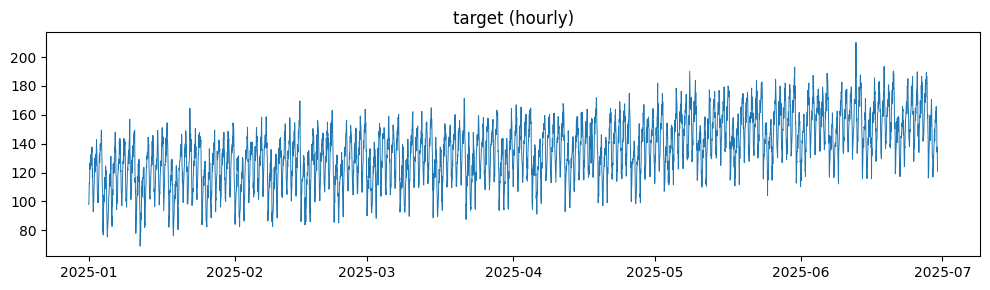

Temporal split (indices): train [0, 3024), val [3024, 3672), test [3672, 4320)
Temporal split (dates): train ≤ 2025-05-06 23:00:00 | val ≤ 2025-06-02 23:00:00 | test through 2025-06-29 23:00:00
epoch 1/5 train_loss=0.658338 val_mae=12.1021
epoch 2/5 train_loss=0.350192 val_mae=8.5566
epoch 3/5 train_loss=0.197423 val_mae=6.2657
epoch 4/5 train_loss=0.164505 val_mae=6.1831
epoch 5/5 train_loss=0.157048 val_mae=6.1403
Best by val MAE: R1
HW12 artifacts -> /Users/cvacushka/Desktop/aie-student-template/homeworks/HW12/artifacts


In [3]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for d in (_here, _here / "HW12", _here / "homeworks" / "HW12"):
    if (d / "hw12_run.py").is_file():
        sys.path.insert(0, str(d))
        break
else:
    raise FileNotFoundError("Положите ноутбук рядом с hw12_run.py или запускайте из homeworks/ / корня репо.")

from hw12_run import run_hw12

run_hw12()

In [ ]:
# Explicit, reproducible pipeline in notebook (B1, B2, B3, R1)
# NOTE: this cell mirrors the required logic and can be run end-to-end if needed.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------- 1) Temporal split: train / validation / test --------------------
assert "date" in df.columns and "target" in df.columns, "Expected df with ['date', 'target'] from previous cell"
df = df.sort_values("date").reset_index(drop=True)

N = len(df)
train_end = int(N * 0.70)
val_end = int(N * 0.85)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Temporal split (indices): train [0, {train_end}), validation [{train_end}, {val_end}), test [{val_end}, {N})")
print(f"Temporal split (dates): train <= {train_df['date'].max()} | validation <= {validation_df['date'].max()} | test <= {test_df['date'].max()}")

# Visualization of train / validation / test split
plt.figure(figsize=(12, 4))
plt.plot(train_df["date"], train_df["target"], label="train", lw=1.0)
plt.plot(validation_df["date"], validation_df["target"], label="validation", lw=1.0)
plt.plot(test_df["date"], test_df["target"], label="test", lw=1.0)
plt.title("Temporal split: train / validation / test")
plt.legend()
plt.tight_layout()
plt.show()


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# -------------------- 2) Baseline B1: naive-last --------------------
# Forecast at t equals previous target value at t-1
b1_df = df[["date", "target"]].copy()
b1_df["pred_b1_naive_last"] = b1_df["target"].shift(1)

b1_val = b1_df.iloc[train_end:val_end].dropna()
b1_test = b1_df.iloc[val_end:].dropna()

b1_val_mae = mean_absolute_error(b1_val["target"], b1_val["pred_b1_naive_last"])
b1_val_rmse = rmse(b1_val["target"], b1_val["pred_b1_naive_last"])
print(f"B1 (naive-last) validation: MAE={b1_val_mae:.4f}, RMSE={b1_val_rmse:.4f}")


# -------------------- 3) Baseline B2: seasonal naive (lag 24) --------------------
b2_df = df[["date", "target"]].copy()
b2_df["pred_b2_lag24"] = b2_df["target"].shift(24)

b2_val = b2_df.iloc[train_end:val_end].dropna()
b2_val_mae = mean_absolute_error(b2_val["target"], b2_val["pred_b2_lag24"])
b2_val_rmse = rmse(b2_val["target"], b2_val["pred_b2_lag24"])
print(f"B2 (lag-24) validation: MAE={b2_val_mae:.4f}, RMSE={b2_val_rmse:.4f}")


# -------------------- 4) Baseline B3: LinearRegression + scaler/normalization --------------------
feat = df[["date", "target"]].copy()
feat["lag_1"] = feat["target"].shift(1)
feat["lag_7"] = feat["target"].shift(7)
feat["lag_14"] = feat["target"].shift(14)
feat["rolling_mean_7"] = feat["target"].shift(1).rolling(7).mean()
feat["rolling_std_7"] = feat["target"].shift(1).rolling(7).std()
feat["dayofweek"] = feat["date"].dt.dayofweek
feat = feat.dropna().reset_index(drop=True)

# Rebuild split after dropna to keep temporal consistency
Nf = len(feat)
train_end_f = int(Nf * 0.70)
val_end_f = int(Nf * 0.85)

train_feat = feat.iloc[:train_end_f]
validation_feat = feat.iloc[train_end_f:val_end_f]
test_feat = feat.iloc[val_end_f:]

X_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dayofweek"]

X_train = train_feat[X_cols].values
y_train = train_feat["target"].values.reshape(-1, 1)
X_val = validation_feat[X_cols].values
y_val = validation_feat["target"].values.reshape(-1, 1)
X_test = test_feat[X_cols].values
y_test = test_feat["target"].values.reshape(-1, 1)

# scaler / normalization: fit only on train
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_sc = x_scaler.fit_transform(X_train)
X_val_sc = x_scaler.transform(X_val)
X_test_sc = x_scaler.transform(X_test)
y_train_sc = y_scaler.fit_transform(y_train).ravel()

b3_model = LinearRegression()  # B3 can be Ridge or LinearRegression
b3_model.fit(X_train_sc, y_train_sc)

b3_val_pred_sc = b3_model.predict(X_val_sc).reshape(-1, 1)
b3_val_pred = y_scaler.inverse_transform(b3_val_pred_sc).ravel()

b3_val_mae = mean_absolute_error(y_val.ravel(), b3_val_pred)
b3_val_rmse = rmse(y_val.ravel(), b3_val_pred)
print(f"B3 (LinearRegression) validation: MAE={b3_val_mae:.4f}, RMSE={b3_val_rmse:.4f}")


# -------------------- 5) R1: GRU with window_size + Dataset + DataLoader --------------------
window_size = 24

series_scaler = StandardScaler()
train_series = train_df[["target"]].values
val_series = validation_df[["target"]].values
test_series = test_df[["target"]].values

train_series_sc = series_scaler.fit_transform(train_series).astype(np.float32)  # fit on train only
val_series_sc = series_scaler.transform(val_series).astype(np.float32)
test_series_sc = series_scaler.transform(test_series).astype(np.float32)


class WindowDataset(Dataset):
    def __init__(self, values_2d: np.ndarray, window_size: int):
        self.values = values_2d
        self.window_size = window_size

    def __len__(self):
        return max(0, len(self.values) - self.window_size)

    def __getitem__(self, idx):
        x = self.values[idx : idx + self.window_size]                 # [window_size, 1]
        y = self.values[idx + self.window_size]                       # [1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_ds = WindowDataset(train_series_sc, window_size=window_size)
validation_ds = WindowDataset(val_series_sc, window_size=window_size)
test_ds = WindowDataset(test_series_sc, window_size=window_size)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
validation_loader = DataLoader(validation_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)


class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


model = GRURegressor().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_val_mae = float("inf")
best_path = os.path.join("artifacts", "best_gru.pt")
os.makedirs("artifacts", exist_ok=True)

for epoch in range(1, 6):
    model.train()  # explicit train mode
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()  # explicit eval mode
    val_pred_sc = []
    val_true_sc = []
    with torch.no_grad():  # or torch.inference_mode()
        for xb, yb in validation_loader:
            xb = xb.to(DEVICE)
            pred = model(xb).cpu().numpy()
            val_pred_sc.append(pred)
            val_true_sc.append(yb.numpy())

    if len(val_pred_sc) > 0:
        val_pred_sc = np.vstack(val_pred_sc)
        val_true_sc = np.vstack(val_true_sc)
        val_pred = series_scaler.inverse_transform(val_pred_sc).ravel()
        val_true = series_scaler.inverse_transform(val_true_sc).ravel()
        val_mae = mean_absolute_error(val_true, val_pred)  # validation metric
    else:
        val_mae = float("inf")

    print(f"epoch {epoch}/5 train_loss={np.mean(train_losses):.6f} val_mae={val_mae:.4f}")

    # save best by validation
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_path)


# -------------------- 6) Final test evaluation of the best approach --------------------
# Load best GRU by validation and evaluate on test split
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

test_pred_sc = []
test_true_sc = []
with torch.inference_mode():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        test_pred_sc.append(pred)
        test_true_sc.append(yb.numpy())

if len(test_pred_sc) > 0:
    test_pred_sc = np.vstack(test_pred_sc)
    test_true_sc = np.vstack(test_true_sc)
    test_pred = series_scaler.inverse_transform(test_pred_sc).ravel()
    test_true = series_scaler.inverse_transform(test_true_sc).ravel()

    r1_test_mae = mean_absolute_error(test_true, test_pred)
    r1_test_rmse = rmse(test_true, test_pred)
    print(f"R1 (GRU, best by validation) test: MAE={r1_test_mae:.4f}, RMSE={r1_test_rmse:.4f}")

# Explicit experiment names required in report/checks
print("Experiments included: B1, B2, B3, R1")